In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df1 = pd.read_csv("aeslabel.csv")
df2 = pd.read_csv("aestraining.csv")
df1.head(), df2.head()


(   0
 0  1
 1  0
 2  0
 3  0
 4  1,
     9.4191   1.1647   4.4388
 0  0.58918  0.50822  0.46485
 1  2.56800  7.97580  4.75890
 2  3.14890  8.28130  3.68200
 3  4.98140  4.13860  9.48360
 4  1.56910  8.71210  9.98970)

In [7]:
df1.columns = ["Label"] 
df2.columns = [f"Feature_{i}" for i in range(1, df2.shape[1] + 1)]
df_combined = pd.concat([df2, df1], axis=1)
df_combined.head()

,Feature_1,Feature_2,Feature_3,Label
0,0.58918,0.50822,0.46485,1
1,2.56800,7.97580,4.75890,0
2,3.14890,8.28130,3.68200,0
3,4.98140,4.13860,9.48360,0
4,1.56910,8.71210,9.98970,1


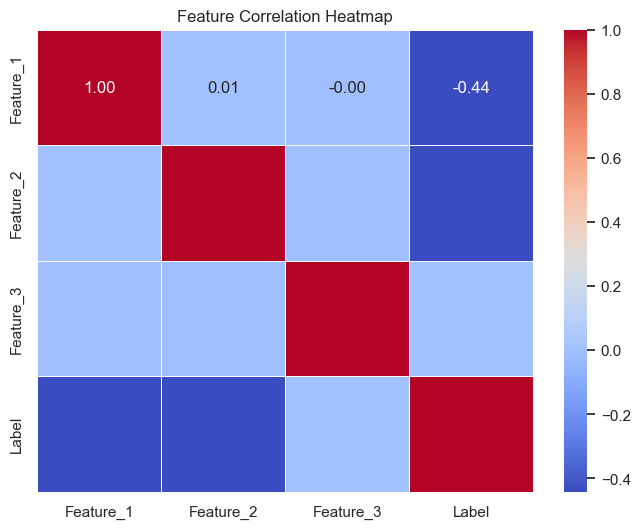

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.figure(figsize=(8, 6))
sns.heatmap(df_combined.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119:

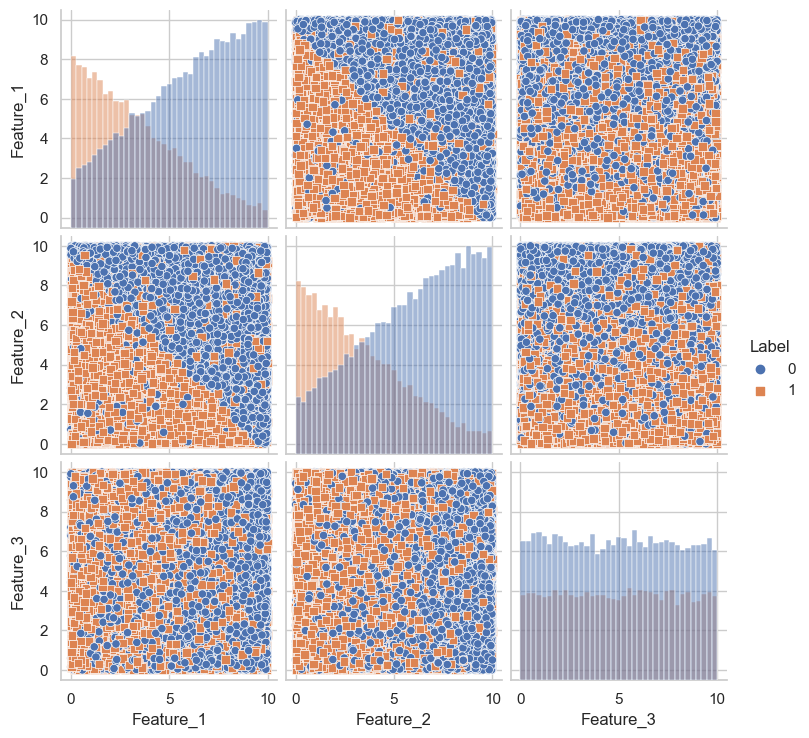

In [9]:
sns.pairplot(df_combined, hue="Label", diag_kind="hist", markers=["o", "s"])
plt.show()


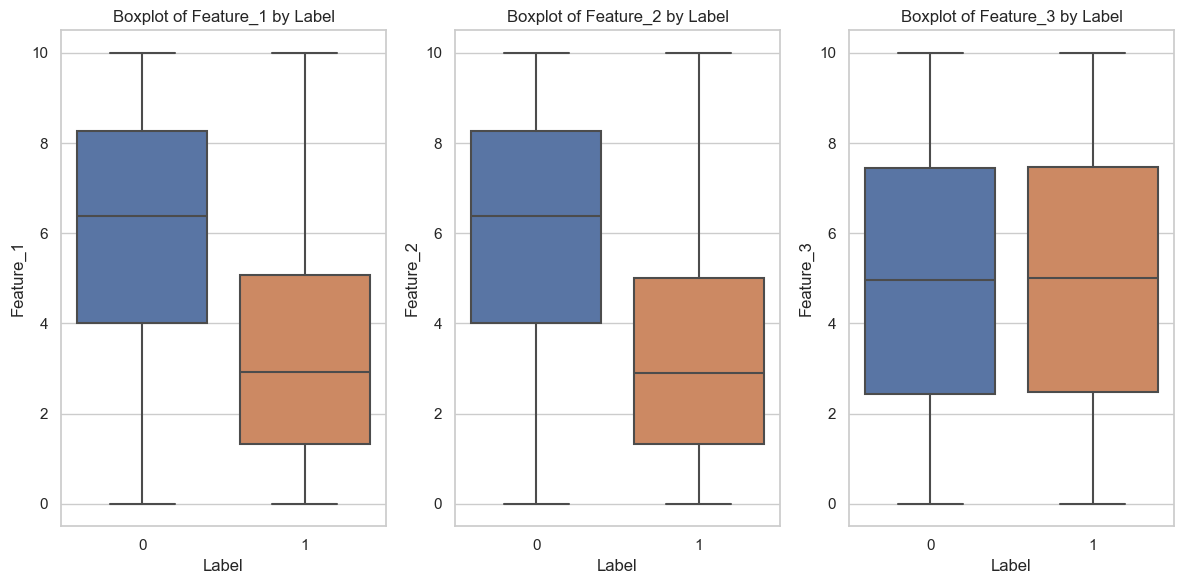

In [10]:
plt.figure(figsize=(12, 6))
for i, feature in enumerate(["Feature_1", "Feature_2", "Feature_3"], 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x="Label", y=feature, data=df_combined)
    plt.title(f"Boxplot of {feature} by Label")
plt.tight_layout()
plt.show()


c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119:

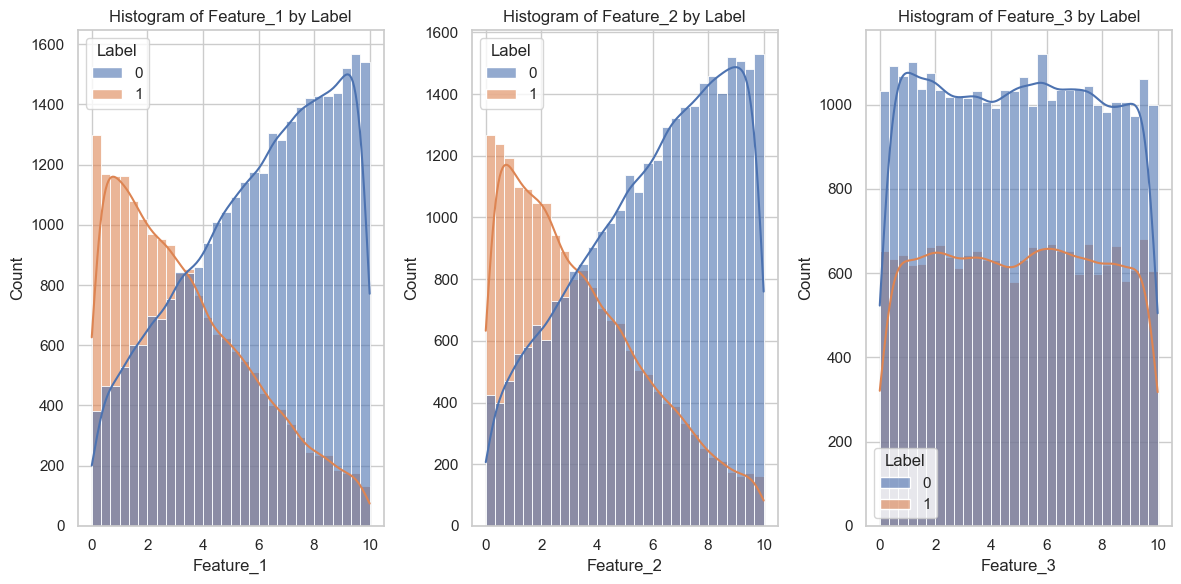

In [11]:
plt.figure(figsize=(12, 6))
for i, feature in enumerate(["Feature_1", "Feature_2", "Feature_3"], 1):
    plt.subplot(1, 3, i)
    sns.histplot(data=df_combined, x=feature, hue="Label", kde=True, bins=30, alpha=0.6)
    plt.title(f"Histogram of {feature} by Label")
plt.tight_layout()
plt.show()


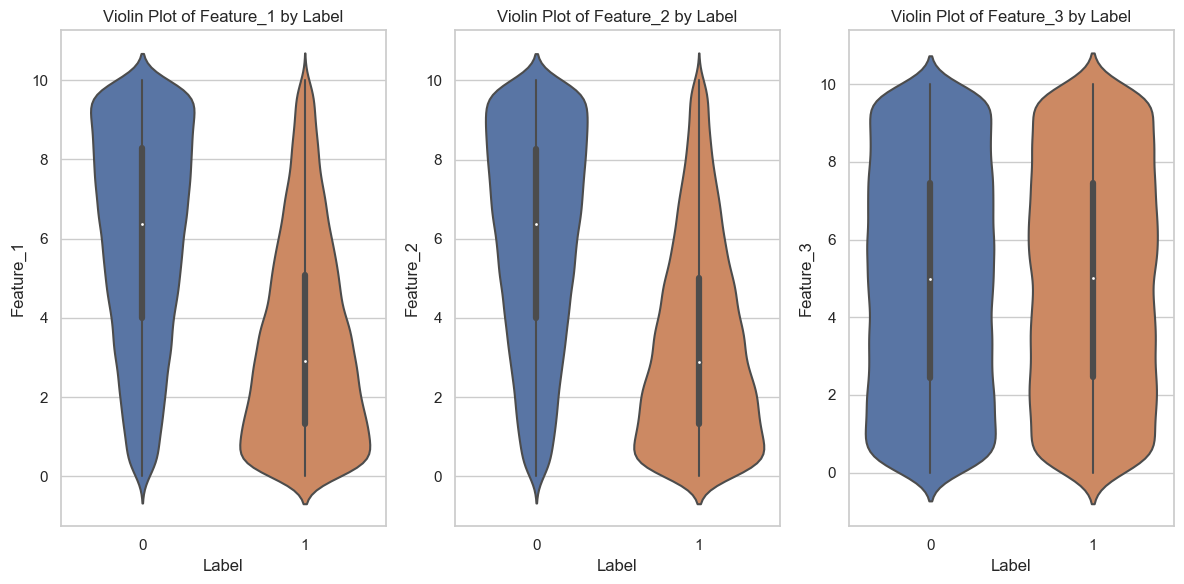

In [12]:
plt.figure(figsize=(12, 6))
for i, feature in enumerate(["Feature_1", "Feature_2", "Feature_3"], 1):
    plt.subplot(1, 3, i)
    sns.violinplot(x="Label", y=feature, data=df_combined)
    plt.title(f"Violin Plot of {feature} by Label")
plt.tight_layout()
plt.show()


In [13]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

X = df_combined.drop(columns=["Label"])
y = df_combined["Label"]

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X, y)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": clf.feature_importances_
}).sort_values(by="Importance", ascending=False)
feature_importance

,Feature,Importance
0,Feature_1,0.426794
1,Feature_2,0.412455
2,Feature_3,0.160751


c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 l

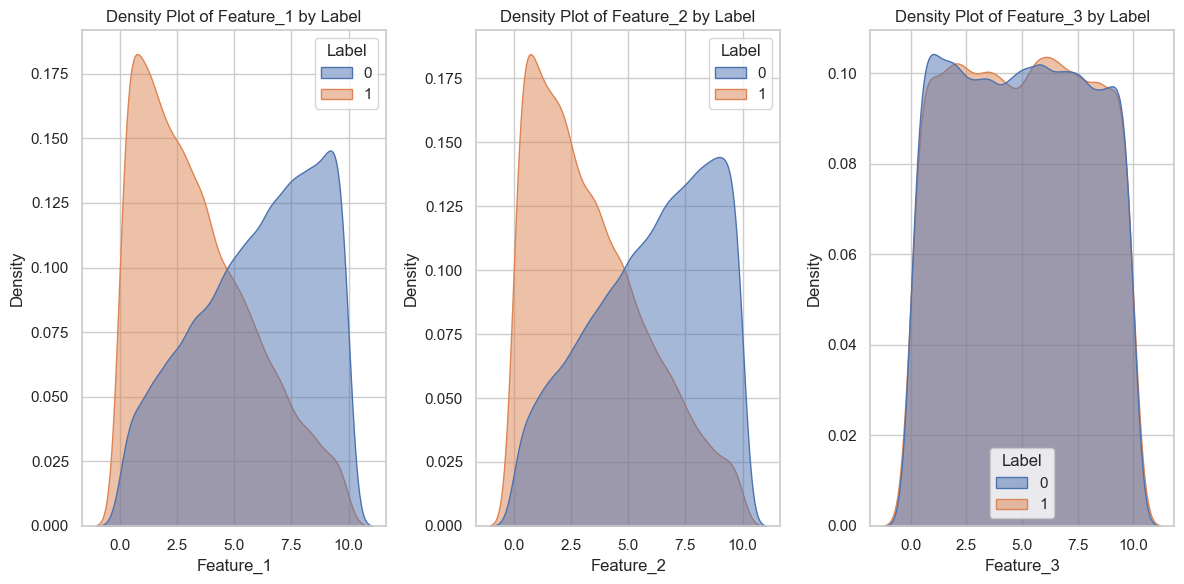

In [14]:
plt.figure(figsize=(12, 6))
for i, feature in enumerate(["Feature_1", "Feature_2", "Feature_3"], 1):
    plt.subplot(1, 3, i)
    sns.kdeplot(data=df_combined, x=feature, hue="Label", fill=True, common_norm=False, alpha=0.5)
    plt.title(f"Density Plot of {feature} by Label")
plt.tight_layout()
plt.show()


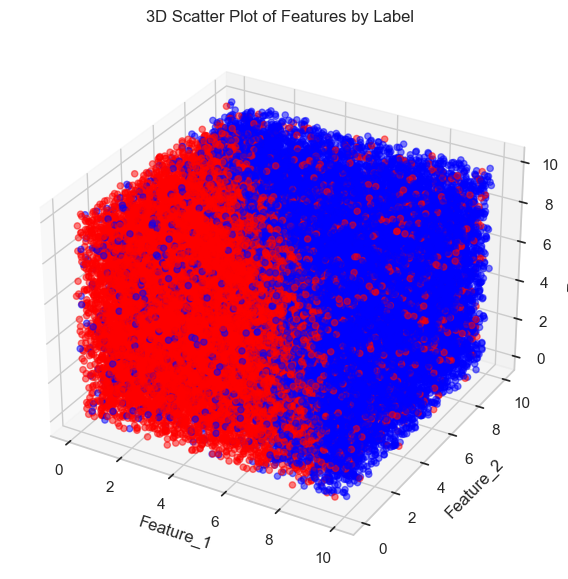

In [15]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

colors = {0: 'blue', 1: 'red'}
ax.scatter(df_combined["Feature_1"], df_combined["Feature_2"], df_combined["Feature_3"], 
           c=df_combined["Label"].map(colors), alpha=0.5)

ax.set_xlabel("Feature_1")
ax.set_ylabel("Feature_2")
ax.set_zlabel("Feature_3")
ax.set_title("3D Scatter Plot of Features by Label")

plt.show()


C:\Users\arman.manoukyan\AppData\Local\Temp\ipykernel_28640\1480777670.py:13: DeprecationWarning: Please import `gaussian_kde` from the `scipy.stats` namespace; the `scipy.stats.kde` namespace is deprecated and will be removed in SciPy 2.0.0.
  k = kde.gaussian_kde([x, y])


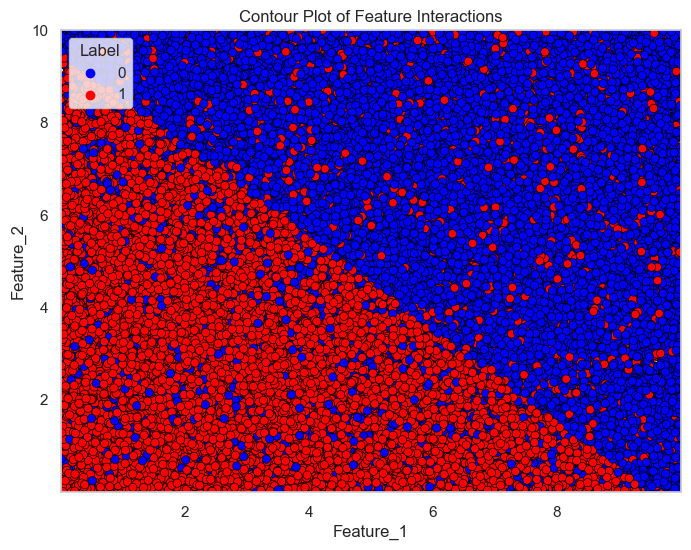

In [16]:
import numpy as np
from scipy.stats import kde

plt.figure(figsize=(8, 6))

feature_x = "Feature_1"
feature_y = "Feature_2"

x = df_combined[feature_x]
y = df_combined[feature_y]
z = df_combined["Label"]

k = kde.gaussian_kde([x, y])
xi, yi = np.meshgrid(np.linspace(x.min(), x.max(), 100), np.linspace(y.min(), y.max(), 100))
zi = k(np.vstack([xi.flatten(), yi.flatten()]))

plt.contourf(xi, yi, zi.reshape(xi.shape), alpha=0.5, cmap="coolwarm")
sns.scatterplot(x=x, y=y, hue=z, palette={0: "blue", 1: "red"}, edgecolor="black")
plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.title("Contour Plot of Feature Interactions")

plt.show()


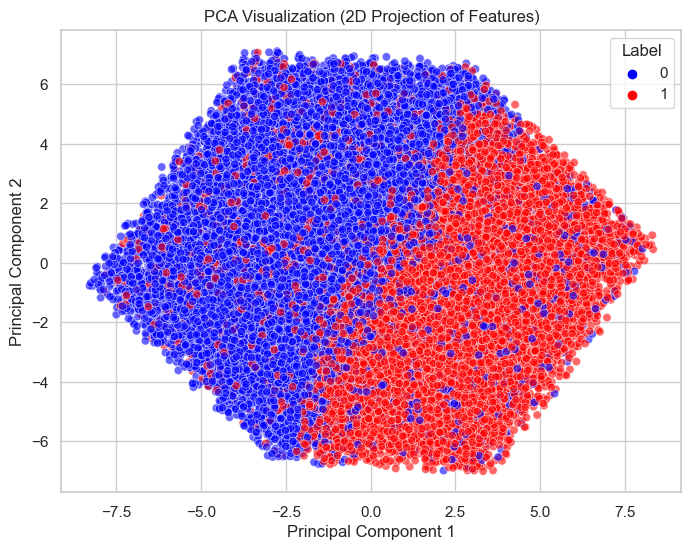

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_combined.drop(columns=["Label"]))

df_pca = pd.DataFrame(df_pca, columns=["PC1", "PC2"])
df_pca["Label"] = df_combined["Label"]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="Label", palette={0: "blue", 1: "red"}, alpha=0.6)
plt.title("PCA Visualization (2D Projection of Features)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


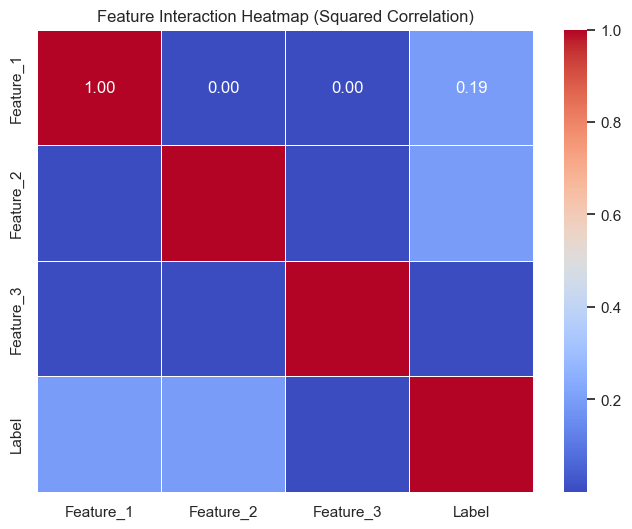

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_combined.corr()**2, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Interaction Heatmap (Squared Correlation)")
plt.show()


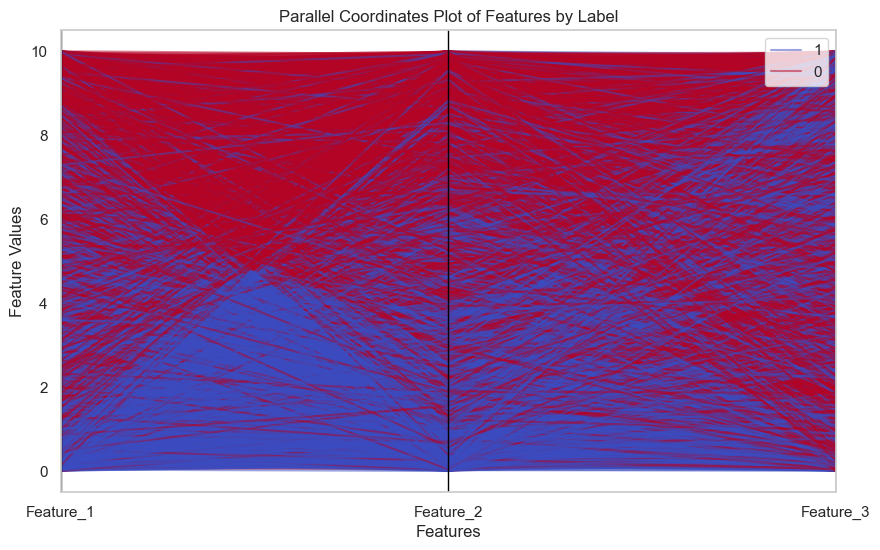

In [19]:
from pandas.plotting import parallel_coordinates

plt.figure(figsize=(10, 6))
parallel_coordinates(df_combined, class_column="Label", colormap="coolwarm", alpha=0.5)
plt.title("Parallel Coordinates Plot of Features by Label")
plt.xlabel("Features")
plt.ylabel("Feature Values")
plt.show()


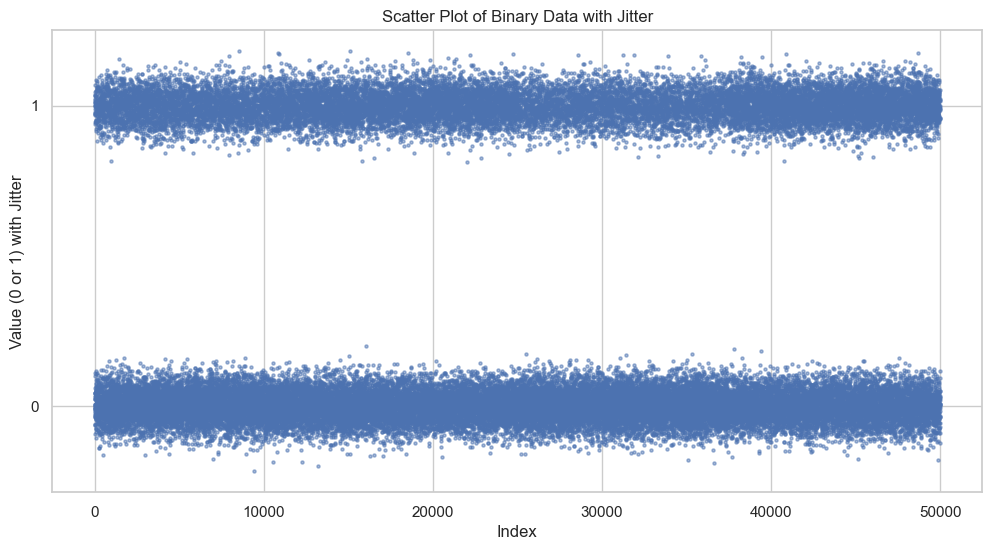

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load data
df = pd.read_csv('aeslabel.csv', header=None)
data = df[0].tolist()

# Scatter plot with jitter
plt.figure(figsize=(12, 6))
x = np.arange(len(data))
y = data + np.random.normal(0, 0.05, len(data))  # Add jitter to y-values
plt.scatter(x, y, s=5, alpha=0.5)  # 's' controls marker size, 'alpha' controls transparency
plt.xlabel("Index")
plt.ylabel("Value (0 or 1) with Jitter")
plt.title("Scatter Plot of Binary Data with Jitter")
plt.yticks([0, 1])
plt.grid(True)
plt.show()


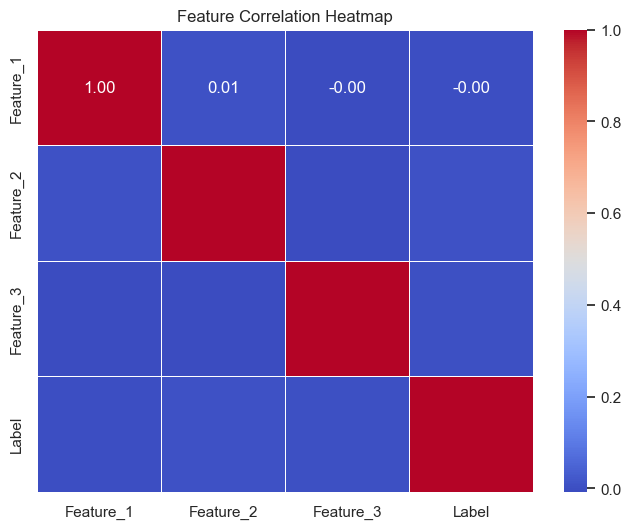

c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 l

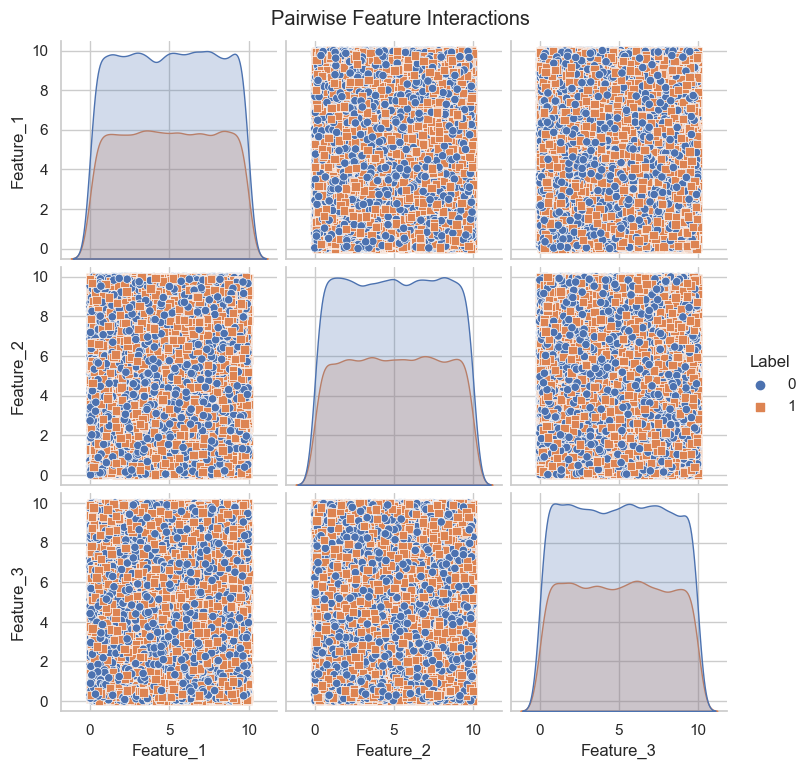

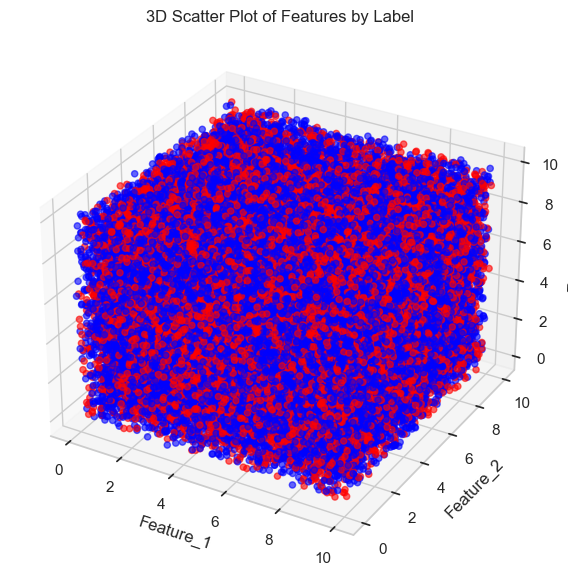

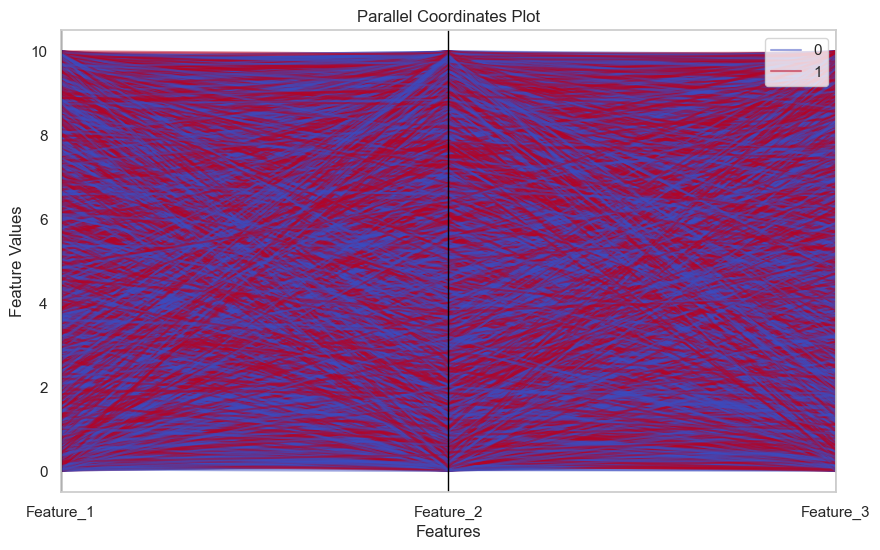

c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 l

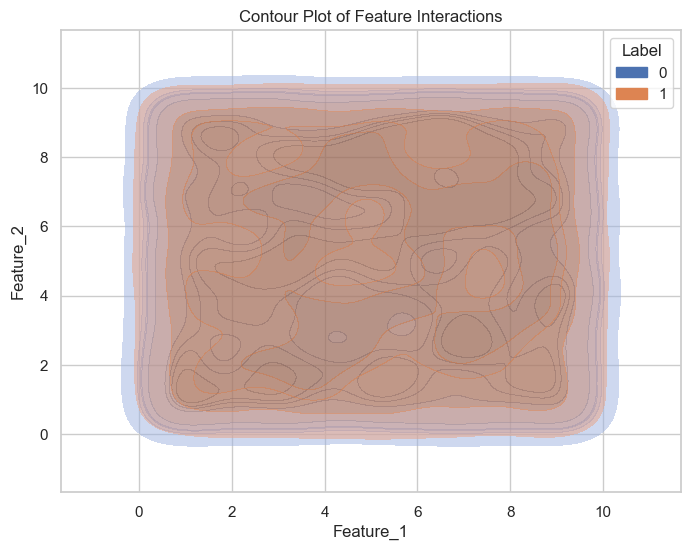

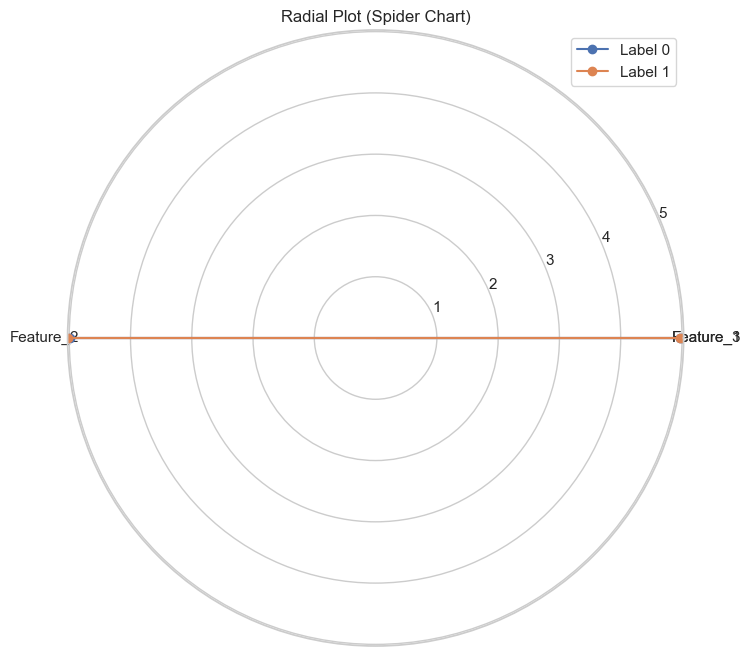

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from pandas.plotting import parallel_coordinates
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Load datasets
aeslabel = pd.read_csv('aeslabel.csv', names=["Label"])  # Assuming single column
aestraining = pd.read_csv("aestraining.csv")
aestraining.columns = [f"Feature_{i+1}" for i in range(aestraining.shape[1])]

# Merge datasets
df = pd.concat([aestraining, aeslabel], axis=1)

# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# Pairwise Feature Interaction Grid (Pairplot)
g = sns.pairplot(df, hue="Label", diag_kind="kde", markers=["o", "s"])
g.fig.suptitle("Pairwise Feature Interactions", y=1.02)
plt.show()

# 3D Scatter Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
colors = {0: 'blue', 1: 'red'}
ax.scatter(df["Feature_1"], df["Feature_2"], df["Feature_3"], c=df["Label"].map(colors), alpha=0.6)
ax.set_xlabel("Feature_1")
ax.set_ylabel("Feature_2")
ax.set_zlabel("Feature_3")
ax.set_title("3D Scatter Plot of Features by Label")
plt.show()

# Parallel Coordinates Plot
plt.figure(figsize=(10, 6))
parallel_coordinates(df, class_column="Label", colormap="coolwarm", alpha=0.5)
plt.title("Parallel Coordinates Plot")
plt.xlabel("Features")
plt.ylabel("Feature Values")
plt.show()

# Contour Plot
plt.figure(figsize=(8, 6))
x, y = df["Feature_1"], df["Feature_2"]
kde = sns.kdeplot(x=x, y=y, hue=df["Label"], fill=True, alpha=0.5)
kde.set(title="Contour Plot of Feature Interactions")
plt.show()


# Radial (Spider) Plot
feature_means = df.groupby("Label").mean()
labels = feature_means.columns
theta = np.linspace(0, 2 * np.pi, len(labels), endpoint=True)
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})
for label, row in feature_means.iterrows():
    ax.plot(theta, row, label=f"Label {label}", marker='o')
ax.set_xticks(theta)
ax.set_xticklabels(labels)
plt.title("Radial Plot (Spider Chart)")
plt.legend()
plt.show()


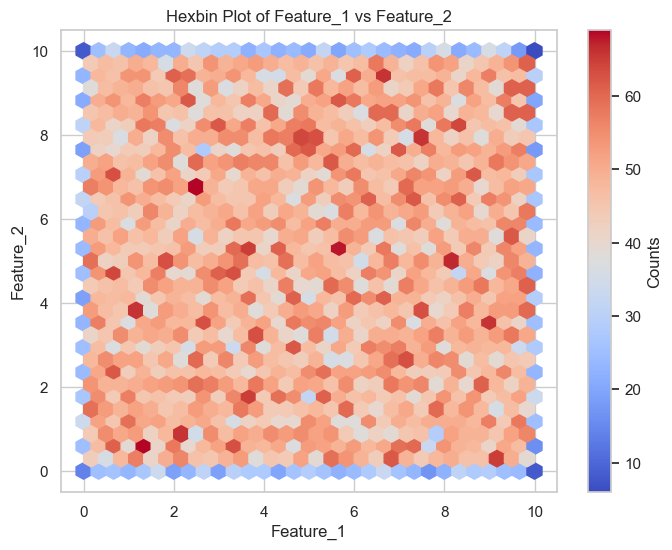

In [24]:
# Hexbin Plot
plt.figure(figsize=(8, 6))
plt.hexbin(df["Feature_1"], df["Feature_2"], gridsize=30, cmap='coolwarm', mincnt=1)
plt.colorbar(label='Counts')
plt.xlabel("Feature_1")
plt.ylabel("Feature_2")
plt.title("Hexbin Plot of Feature_1 vs Feature_2")
plt.show()


c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future

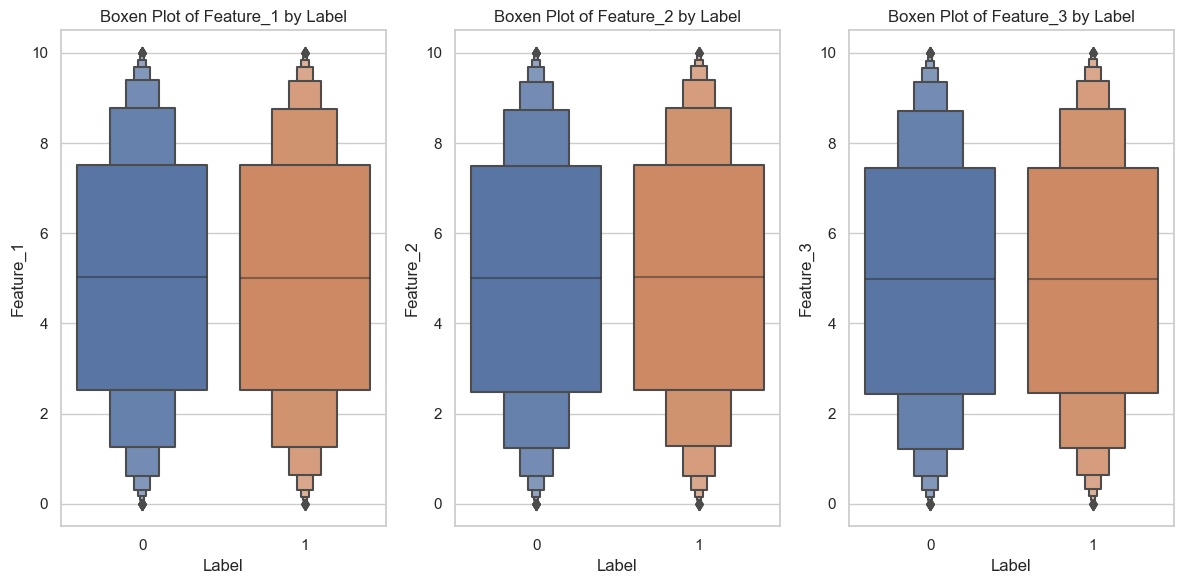

In [25]:
plt.figure(figsize=(12, 6))
for i, feature in enumerate(["Feature_1", "Feature_2", "Feature_3"], 1):
    plt.subplot(1, 3, i)
    sns.boxenplot(x="Label", y=feature, data=df)
    plt.title(f"Boxen Plot of {feature} by Label")
plt.tight_layout()
plt.show()

In [32]:
# Check for missing values in the dataset
missing_values = df.isna().sum()
print(missing_values)


Feature_1    1
Feature_2    1
Feature_3    1
Label        0
dtype: int64


In [33]:
df_cleaned = df.dropna()


c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


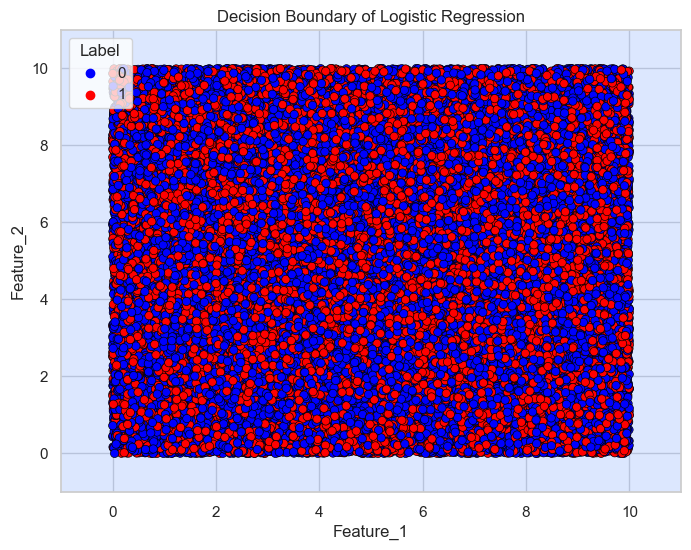

c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 l

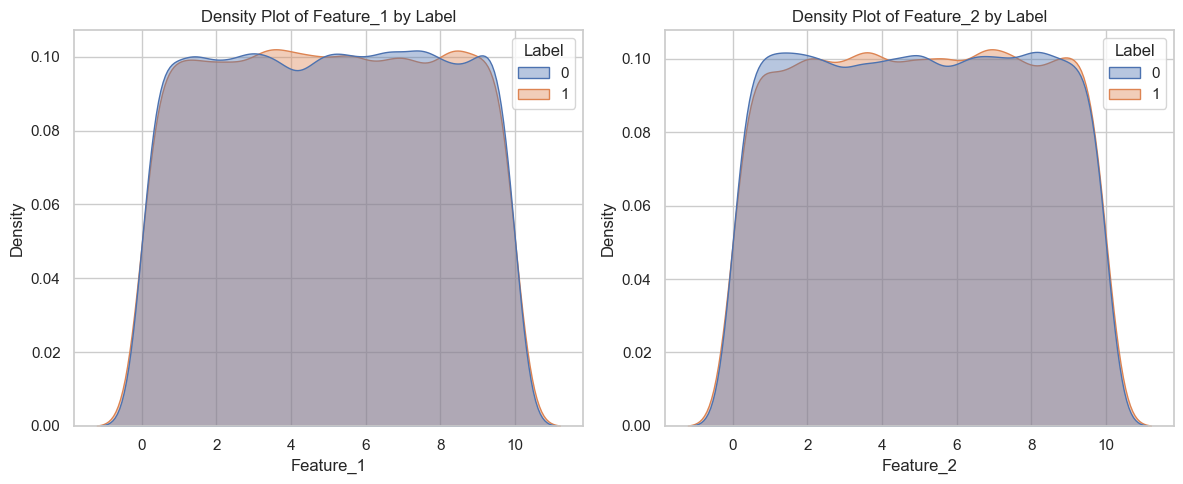

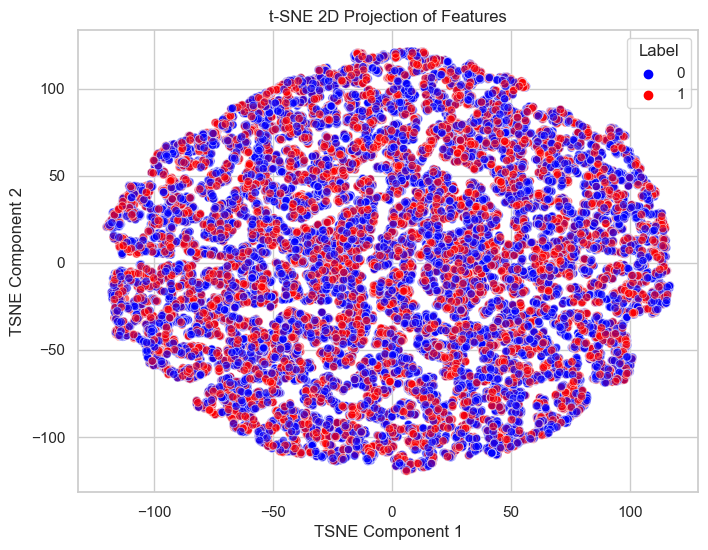

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.manifold import TSNE

# Prepare data
X = df_cleaned[["Feature_1", "Feature_2"]]  
y = df_cleaned["Label"]

# 1️⃣ Decision Boundary Plot
clf = LogisticRegression()
clf.fit(X, y)

# Create a grid of Feature_1 and Feature_2 values
x_min, x_max = X["Feature_1"].min() - 1, X["Feature_1"].max() + 1
y_min, y_max = X["Feature_2"].min() - 1, X["Feature_2"].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
sns.scatterplot(x=X["Feature_1"], y=X["Feature_2"], hue=y, palette={0: "blue", 1: "red"}, edgecolor="black")
plt.xlabel("Feature_1")
plt.ylabel("Feature_2")
plt.title("Decision Boundary of Logistic Regression")
plt.show()

# 2️⃣ Feature Distribution Overlap Plot
plt.figure(figsize=(12, 5))
for i, feature in enumerate(["Feature_1", "Feature_2"], 1):
    plt.subplot(1, 2, i)
    sns.kdeplot(data=df, x=feature, hue="Label", fill=True, common_norm=False, alpha=0.4)
    plt.title(f"Density Plot of {feature} by Label")
plt.tight_layout()
plt.show()

# 3️⃣ Feature Importance Using Permutation Scores
model = LogisticRegression()
model.fit(df_cleaned[["Feature_1", "Feature_2", "Feature_3"]], df_cleaned["Label"])
importance = permutation_importance(model, df_cleaned[["Feature_1", "Feature_2", "Feature_3"]], df_cleaned["Label"], n_repeats=10, random_state=42)

feature_importance_df = pd.DataFrame({
    "Feature": ["Feature_1", "Feature_2", "Feature_3"],
    "Importance": importance["importances_mean"]
}).sort_values(by="Importance", ascending=False)

# 4️⃣ TSNE 2D Projection
tsne = TSNE(n_components=2, random_state=42)
df_tsne = tsne.fit_transform(df_cleaned.drop(columns=["Label"]))

df_tsne = pd.DataFrame(df_tsne, columns=["TSNE1", "TSNE2"])
df_tsne["Label"] = df_cleaned["Label"]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_tsne, x="TSNE1", y="TSNE2", hue="Label", palette={0: "blue", 1: "red"}, alpha=0.6)
plt.title("t-SNE 2D Projection of Features")
plt.xlabel("TSNE Component 1")
plt.ylabel("TSNE Component 2")
plt.show()


c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\arman.manoukyan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\arman.manoukyan\

Accuracy: 0.6161

Classification Report:
               precision    recall  f1-score   support

           0       0.62      1.00      0.76      6161
           1       0.00      0.00      0.00      3839

    accuracy                           0.62     10000
   macro avg       0.31      0.50      0.38     10000
weighted avg       0.38      0.62      0.47     10000


Confusion Matrix:
 [[6161    0]
 [3839    0]]


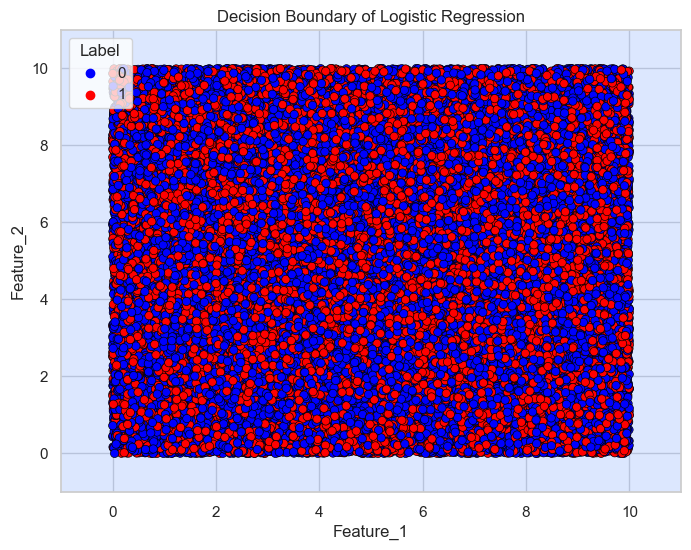

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Prepare data (excluding Feature_3 since it's not useful)
X = df_cleaned[["Feature_1", "Feature_2"]]
y = df_cleaned["Label"]

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression model
clf = LogisticRegression()
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Display Results
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_rep)
print("\nConfusion Matrix:\n", conf_matrix)

# Visualizing Decision Boundary
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create mesh grid
x_min, x_max = X["Feature_1"].min() - 1, X["Feature_1"].max() + 1
y_min, y_max = X["Feature_2"].min() - 1, X["Feature_2"].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
sns.scatterplot(x=X["Feature_1"], y=X["Feature_2"], hue=y, palette={0: "blue", 1: "red"}, edgecolor="black")
plt.xlabel("Feature_1")
plt.ylabel("Feature_2")
plt.title("Decision Boundary of Logistic Regression")
plt.show()
